COURTROOM ANALIZER

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# =========================
# 2. Install required libraries
# =========================
# Ultralytics is used for YOLO object detection.
# Whisper is used for transcribing the audio from the courtroom video.
# Sentence-transformers is used for the transcript chatbot.

!pip install -q ultralytics openai-whisper sentence-transformers

In [18]:
# =========================
# 3. Import libraries
# =========================
# These libraries are used for the model, transcription, text processing, and file handling.

from ultralytics import YOLO
import whisper
import os
import re
from collections import Counter

In [4]:
# =========================
# 4. Set file paths
# =========================
# These paths point to the trained YOLO model and the courtroom video saved in Google Drive.

MODEL_PATH = "/content/drive/MyDrive/courtroom_project/best.pt"
VIDEO_PATH = "/content/drive/MyDrive/courtroom_project/testing 2.mp4"

# This is where the final video with bounding boxes and audio will be saved.
FINAL_VIDEO = "/content/drive/MyDrive/courtroom_project/final_with_audio_fixed.mp4"

In [5]:
# =========================
# 5. Load YOLO model
# =========================
# This loads the trained YOLO model that detects courtroom objects.

model = YOLO(MODEL_PATH)

In [6]:
# =========================
# 6. Test picture number one
# =========================
# This tests the model on one image to make sure the object detection works.

from google.colab import files
uploaded = files.upload()

results = model.predict("testing.jpg", show=True)
model.predict("testing.jpg", save=True)

Saving testing.jpg to testing (1).jpg
WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


image 1/1 /content/testing.jpg: 448x640 2 flags, 4 judge benchs, 5 persons, 21.1ms
Speed: 1.2ms preprocess, 21.1ms inference, 8.2ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/testing.jpg: 448x640 2 flags, 4 judge benchs, 5 persons, 2.4ms
Speed: 1.1ms preprocess, 2.4ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict-2


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'flag', 1: 'judge bench', 2: 'microphone', 3: 'person'}
 obb: None
 orig_img: array([[[255, 254, 255],
         [255, 254, 255],
         [255, 254, 255],
         ...,
         [188, 204, 221],
         [190, 206, 223],
         [187, 203, 220]],
 
        [[255, 254, 255],
         [255, 254, 255],
         [255, 254, 255],
         ...,
         [194, 210, 227],
         [189, 205, 222],
         [190, 206, 223]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [191, 205, 223],
         [190, 204, 222],
         [186, 200, 218]],
 
        ...,
 
        [[  0,  40,  93],
         [  0,  40,  93],
         [  1,  39,  93],
         ...,
         [  0,   4,  37],
         [  0,   5,  38],
         [  0,   5,  38]],
 
        [[  0,  40,  93],
         [  0,  40,  93],
         [  

(np.float64(-0.5), np.float64(499.5), np.float64(332.5), np.float64(-0.5))

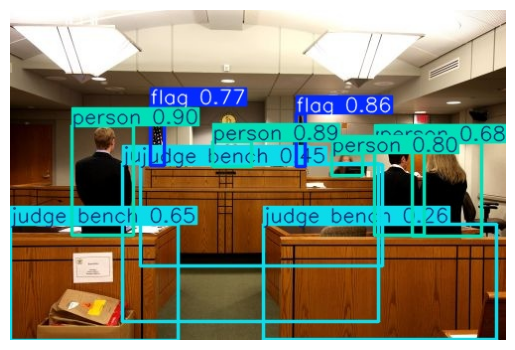

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

save_dir = results[0].save_dir
img_path = os.path.join(save_dir, "testing.jpg")

img = Image.open(img_path)
plt.imshow(img)
plt.axis("off")

In [7]:
# =========================
# 7. Test picture number two
# =========================
# This tests the model on one image to make sure the object detection works.

from google.colab import files
uploaded = files.upload()

results = model.predict("testing 2.jpg", save=True)

Saving testing_2.jpg to testing_2.jpg

image 1/1 /content/testing 2.jpg: 640x448 1 flag, 2 judge benchs, 3 persons, 13.7ms
Speed: 1.1ms preprocess, 13.7ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 448)
Results saved to /content/runs/detect/predict-2


(np.float64(-0.5), np.float64(1364.5), np.float64(2047.5), np.float64(-0.5))

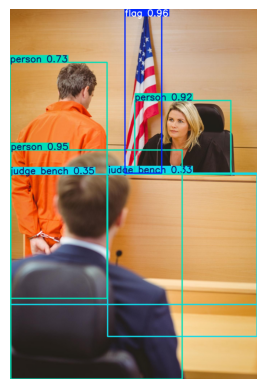

In [8]:
from PIL import Image
import matplotlib.pyplot as plt
import os

save_dir = results[0].save_dir
img_path = os.path.join(save_dir, "testing 2.jpg")

img = Image.open(img_path)
plt.imshow(img)
plt.axis("off")

In [23]:
# =========================
# 8. Test video
# =========================
# This runs the trained YOLO model on the courtroom video.
# The output video will have bounding boxes, but YOLO does not keep the original audio.

results_video = model.predict(
    source=VIDEO_PATH,
    save=True,
    conf=0.5,
    iou=0.4
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/2616) /content/drive/MyDrive/courtroom_project/testing 2.mp4: 384x640 1 person, 2.9ms
video 1/1 (frame 2/2616) /content/drive/MyDrive/courtroom_project/testing 2.mp4: 384x640 1 person, 2.6ms
video 1/1 (frame 3/2616) /content/drive/MyDrive/courtroom_project/testing 2.mp4: 384x640 1 person, 2.5ms
video 1/1 (frame 4/2616) /content/drive/MyDrive/courtroom_project/testing 2.mp4: 384x640 1 person, 2.6ms
video 1/1 (frame 5/2616) /content/driv

In [24]:
results[0].save_dir

'/content/runs/detect/predict-2'

In [26]:
# =========================
# 9. Find YOLO video output
# =========================
# YOLO saves the processed video in the runs/detect/predict folder.
# This lets me confirm the name of the output file.

!ls /content/runs/detect/predict-2

'testing 2.avi'  'testing 2.jpg'   testing.jpg


In [41]:
# =========================
# 10. Add original audio back to YOLO video
# =========================
# YOLO creates the video with bounding boxes but drops the audio.
# This code takes the video from YOLO and the audio from the original video,
# then creates one final MP4 video that should play normally in Windows Media Player.

FINAL_VIDEO = "/content/drive/MyDrive/courtroom_project/final_with_audio_fixed.mp4"

!ffmpeg -y \
-i "$YOLO_VIDEO" \
-i "$VIDEO_PATH" \
-c:v libx264 \
-pix_fmt yuv420p \
-c:a aac \
-b:a 192k \
-map 0:v:0 \
-map 1:a:0 \
-shortest \
"$FINAL_VIDEO"

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [13]:
# =========================
# 11. Download final video
# =========================
# This downloads the final video with bounding boxes and audio.

from google.colab import files
files.download("/content/drive/MyDrive/courtroom_project/final_with_audio.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

NLP Component

In [31]:
# =========================
# 12. Load Whisper model
# =========================
# Whisper is used to convert the courtroom audio into text for the NLP part.

model_whisper = whisper.load_model("base")

# Use the video saved in Google Drive
original_video_path = "/content/drive/MyDrive/courtroom_project/testing 2.mp4"

result = model_whisper.transcribe(original_video_path)

transcript = result["text"]

print(transcript)

 denied all coverage, then there's no appraisal that's appropriate at this time. But if we're just being factually honest, there's been no effort to claw back the coverage that was already advanced, and that I think does color whether or not an appraisal is in order. Well, your honor, again, eventually the insurer did deny coverage and say, we, we, advanced 10% of what they're now claiming is owed. I mean, there's $37 million that they say they're in damages where we have denied coverage on. So I believe that it is accurate, it's accurate to say both. Okay, that we initially provided that, those funds, when we didn't know the actual facts we knew that a hurricane had occurred. We knew that there was damage, frankly, from the hurricane, not even close to the extent that they say. But they never said there was a waiver of denial of coverage because we did not fall back. Well, there couldn't be, there couldn't be a waiver based on something you did before. That's right. They're misconduct

In [32]:
# =========================
# 14. Clean transcript
# =========================
# This removes extra spaces so the transcript is easier to process.

clean_text = re.sub(r'\s+', ' ', transcript).strip()

print(clean_text[:1000])

denied all coverage, then there's no appraisal that's appropriate at this time. But if we're just being factually honest, there's been no effort to claw back the coverage that was already advanced, and that I think does color whether or not an appraisal is in order. Well, your honor, again, eventually the insurer did deny coverage and say, we, we, advanced 10% of what they're now claiming is owed. I mean, there's $37 million that they say they're in damages where we have denied coverage on. So I believe that it is accurate, it's accurate to say both. Okay, that we initially provided that, those funds, when we didn't know the actual facts we knew that a hurricane had occurred. We knew that there was damage, frankly, from the hurricane, not even close to the extent that they say. But they never said there was a waiver of denial of coverage because we did not fall back. Well, there couldn't be, there couldn't be a waiver based on something you did before. That's right. They're misconduct.

In [33]:
# =========================
# 15. Create simple summary
# =========================
# This creates a basic summary by taking the first few meaningful sentences.

sentences = re.split(r'(?<=[.!?]) +', clean_text)

summary = " ".join(sentences[:5])

print("SUMMARY:")
print(summary)

SUMMARY:
denied all coverage, then there's no appraisal that's appropriate at this time. But if we're just being factually honest, there's been no effort to claw back the coverage that was already advanced, and that I think does color whether or not an appraisal is in order. Well, your honor, again, eventually the insurer did deny coverage and say, we, we, advanced 10% of what they're now claiming is owed. I mean, there's $37 million that they say they're in damages where we have denied coverage on. So I believe that it is accurate, it's accurate to say both.


In [34]:
# =========================
# 16. Extract keywords
# =========================
# This finds the most common important words in the transcript.
from collections import Counter

words = re.findall(r'\b[a-zA-Z]{4,}\b', clean_text.lower())

stopwords = {
    "that", "this", "with", "from", "have", "were", "they", "there",
    "would", "could", "should", "your", "about", "because", "court",
    "please", "thank", "good", "morning"
}

filtered_words = [word for word in words if word not in stopwords]

keywords = Counter(filtered_words).most_common(15)

print("KEYWORDS:")
for word, count in keywords:
    print(f"{word}: {count}")

KEYWORDS:
coverage: 6
back: 4
waiver: 4
denied: 3
claw: 3
well: 3
appraisal: 2
advanced: 2
think: 2
eventually: 2
where: 2
accurate: 2
didn: 2
knew: 2
hurricane: 2


In [35]:
# =========================
# NLP: Transcript Chatbot
# =========================

import re

# Split transcript into sentences
sentences = re.split(r'(?<=[.!?]) +', clean_text)

# Group sentences into chunks so the chatbot has enough context
chunks = []
chunk_size = 4

for i in range(0, len(sentences), chunk_size):
    chunk = " ".join(sentences[i:i + chunk_size])
    if len(chunk.strip()) > 0:
        chunks.append(chunk)

print(f"Created {len(chunks)} transcript chunks.")


Created 4 transcript chunks.


In [36]:
# =========================
# 17. Build transcript chatbot
# =========================
# This chatbot searches the transcript and finds the part that best matches the question.
# It is not making up answers. It is pulling answers from the transcript.

from sentence_transformers import SentenceTransformer, util

# This model helps compare the meaning of the question to transcript chunks
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Convert all transcript chunks into embeddings
chunk_embeddings = embedding_model.encode(chunks, convert_to_tensor=True)

print("Transcript chatbot is ready.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Transcript chatbot is ready.


In [37]:
# =========================
# 18. Chatbot function
# =========================
# This function compares the question to each transcript chunk
# and returns the most relevant part of the transcript.

def courtroom_chatbot(question):
    # Convert the user's question into an embedding
    question_embedding = embedding_model.encode(question, convert_to_tensor=True)

    # Compare the question to each transcript chunk
    scores = util.cos_sim(question_embedding, chunk_embeddings)[0]

    # Find the best matching chunk
    best_match_index = scores.argmax().item()
    best_score = scores[best_match_index].item()

    # If the match is weak, explain that the transcript may not contain the answer
    if best_score < 0.25:
        return "I could not find a strong answer in the transcript."

    # Return the most relevant part of the transcript
    return chunks[best_match_index]

In [38]:
# =========================
# 19. Test chatbot
# =========================
# These are example questions to show that the NLP part can answer questions about the video transcript.
print("Courtroom Transcript Chatbot")

question = "What is the issue with coverage?"
answer = courtroom_chatbot(question)

print("Q:", question)
print("A:", answer)

Courtroom Transcript Chatbot
Q: What is the issue with coverage?
A: So I believe that it is accurate, it's accurate to say both. Okay, that we initially provided that, those funds, when we didn't know the actual facts we knew that a hurricane had occurred. We knew that there was damage, frankly, from the hurricane, not even close to the extent that they say. But they never said there was a waiver of denial of coverage because we did not fall back.


In [39]:
questions = [
    "What is the issue with coverage?",
    "What does the speaker say about appraisal?",
    "Was coverage denied?",
    "What legal issue appears in the transcript?"
]

for q in questions:
    print("\nQ:", q)
    print("A:", courtroom_chatbot(q))


Q: What is the issue with coverage?
A: So I believe that it is accurate, it's accurate to say both. Okay, that we initially provided that, those funds, when we didn't know the actual facts we knew that a hurricane had occurred. We knew that there was damage, frankly, from the hurricane, not even close to the extent that they say. But they never said there was a waiver of denial of coverage because we did not fall back.

Q: What does the speaker say about appraisal?
A: denied all coverage, then there's no appraisal that's appropriate at this time. But if we're just being factually honest, there's been no effort to claw back the coverage that was already advanced, and that I think does color whether or not an appraisal is in order. Well, your honor, again, eventually the insurer did deny coverage and say, we, we, advanced 10% of what they're now claiming is owed. I mean, there's $37 million that they say they're in damages where we have denied coverage on.

Q: Was coverage denied?
A: de

In [40]:
# =========================
# 20. Final project output
# =========================
# This final section brings the CV and NLP results together in one place.

print("\n==============================")
print("COURTROOM ANALYZER FINAL OUTPUT")
print("==============================")

print("\nDetected Objects (CV):")
print("Person, Judge Bench, Flag, Microphone")

print("\nTranscript Preview:")
print(clean_text[:500])

print("\nSummary:")
print(summary)

print("\nTop Keywords:")
for word, count in keywords:
    print(f"{word}: {count}")

print("\nChatbot Example:")
print("Q: What legal issue appears in the transcript?")
print("A:", courtroom_chatbot("What legal issue appears in the transcript?"))

print("\nFinal Video Saved At:")
print(FINAL_VIDEO)


COURTROOM ANALYZER FINAL OUTPUT

Detected Objects (CV):
Person, Judge Bench, Flag, Microphone

Transcript Preview:
denied all coverage, then there's no appraisal that's appropriate at this time. But if we're just being factually honest, there's been no effort to claw back the coverage that was already advanced, and that I think does color whether or not an appraisal is in order. Well, your honor, again, eventually the insurer did deny coverage and say, we, we, advanced 10% of what they're now claiming is owed. I mean, there's $37 million that they say they're in damages where we have denied coverage on. So I

Summary:
denied all coverage, then there's no appraisal that's appropriate at this time. But if we're just being factually honest, there's been no effort to claw back the coverage that was already advanced, and that I think does color whether or not an appraisal is in order. Well, your honor, again, eventually the insurer did deny coverage and say, we, we, advanced 10% of what th